Coupled MUG/TokaMaker Example: Blanket MHD during a VDE {#doc_tMaker_blanket_vde_ex}
==========
In this example we demonstrate a coupled MUG/TokaMaker time-dependent simulation of the
magnetohydrodynamic (MHD) response of a conducting blanket during a vertical displacement event (VDE):

1) Set up a TokaMaker Grad-Shafranov equilibrium for a device surrounded by a conducting blanket
2) Compute the linear stability of the equilibrium and seed a VDE with the vertically unstable mode
3) Build a coupled \ref OpenFUSIONToolkit.TokaMaker.mug_tok.MUGToksim "MUGToksim" simulation and advance the plasma equilibrium together with the incompressible MHD flow induced in the conducting blanket regions
4) Retrieve and plot the MHD fields (velocity and current density) returned by the coupled solver

The equilibrium setup below is intentionally brief; see \ref doc_tMaker_DIIID_ex2 for a detailed
walkthrough of building a TokaMaker equilibrium and running a VDE.

**Note:** Running this example requires the [h5py](https://www.h5py.org/) python package.

In [1]:
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

## Load TokaMaker Library

To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or using within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` on macOS).

In [ ]:
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_isoflux, read_eqdsk

## Set up the equilibrium

We now create a \ref OpenFUSIONToolkit.OFT_env "OFT_env" instance for execution using two threads and a \ref OpenFUSIONToolkit.TokaMaker.TokaMaker "TokaMaker" instance to use for equilibrium calculations. 

We load a mesh that includes a conducting **blanket** surrounding the plasma and solve a
free-boundary Grad-Shafranov equilibrium. This follows the standard TokaMaker workflow, so the
steps below are only summarized here (see \ref doc_tMaker_DIIID_ex2 for a detailed explanation):

- \ref OpenFUSIONToolkit.TokaMaker.load_gs_mesh "load_gs_mesh()" reads the mesh points, cell list,
  region IDs, coil dictionary (`coil_dict`), and conductor dictionary (`cond_dict`) from
  `blanket_mesh.h5`. The conducting blanket regions (e.g. `BLANKET_INNER`, `BLANKET_OUTER`) carry a
  resistivity `eta`, and are the regions where the coupled MHD solve will run later.
- \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup_mesh "setup_mesh()",
  \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup_regions "setup_regions()", and
  \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup "setup()" build the solver (here at element
  `order=2` with toroidal field `F0 = B0*R0`).
- Coil regularization, the P'/FF' flux-function profiles, and shape (isoflux/saddle) targets
  constrain the solve, which is run with
  \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.init_psi "init_psi()" followed by
  \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.solve "solve()".

In [3]:
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

#----------------------------------------------
             ____  ____________
            / __ \/ ____/_  __/
           / / / / /_    / /
          / /_/ / __/   / /
          \____/_/     /_/

Base release:        v26.6
Development branch:  mugtok_pr
Revision id:         3db6ce3

Parallelization Info:
  # of MPI tasks      =    1
  # of NUMA nodes     =    1
  # of OpenMP threads =    2

Linear Algebra backend: native

#----------------------------------------------



In [4]:
# Load mesh and setup TokaMaker instance
mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh('blanket_mesh.h5')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.setup(order=2,F0=7.5*4.8)


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.010E+02
    # of points  =    9086
    # of edges   =   27155
    # of cells   =   18070
    # of boundary points =     100
    # of boundary edges  =     100
    # of boundary cells  =      96
  Resolution statistics:
    hmin =  1.284E-02
    hrms =  1.173E-01
    hmax =  6.623E-01
  Surface grounded at vertex    2425


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    1.1050000000000001E-003


In [5]:
#Add regularization terms to PF coils to enforce up/down symmetry and a target current in the central solenoid
coil_reg_mat = np.zeros((mygs.ncoils+1,mygs.ncoils+1), dtype=np.float64)
targets = np.zeros(mygs.ncoils+1)
coil_weights = 0.5*np.ones(mygs.ncoils+1)
coil_weights[0] =10
coil_reg_mat[0,0] = 1

targets[0] = -10.E6

#Enforce up/down symmetry in PF coils
coil_reg_mat[1,1] = 1
coil_reg_mat[1,2] = -1
coil_reg_mat[3,3] = 1
coil_reg_mat[3,4] = -1
coil_reg_mat[5,5] = 1
coil_reg_mat[5,6] = -1

mygs.set_coil_reg(coil_reg_mat, targets, coil_weights)

In [6]:
# Define shape of P' anf FF' profiles
n_sample = 40
psi_sample = np.linspace(0.0,1.0,n_sample)

alpha = 5.0
gamma = 1.25

ffp_prof = {
    'type': 'linterp',
    'x': psi_sample,
    'y': np.power(1.0-np.power(psi_sample,alpha),gamma)
}
ffp_prof['y'] /= ffp_prof['y'][0] # Normalize profile (not required but convienient)

alpha = 5.0
gamma = 1.25
pp_prof = {
    'type': 'linterp',
    'x': psi_sample,
    'y': np.power(1.0-np.power(psi_sample,alpha),gamma)
}
pp_prof['y'] /= pp_prof['y'][0] # Normalize profile (not required but convienient)

mygs.set_profiles(ffp_prof=ffp_prof,pp_prof=pp_prof, keep_files = True)

In [7]:
# set global targets
Ip_target = 7.87E6
mygs.set_targets(Ip = Ip_target, Ip_ratio=.205)

In [8]:
#Set isoflux and saddle constraints to enforce a target plasma shape

boundary = create_isoflux(4, 4.8, 0.0,1.2, 2.0, 0.6)
isoflux_weights = 70*np.ones(len(boundary))
mygs.set_isoflux_constraints(boundary, isoflux_weights)

x_points = np.zeros((2,2))
x_points[0,:] = boundary[np.argmin(boundary[:,1]),:]
x_points[1,:] = boundary[np.argmax(boundary[:,1]),:]
x_weights = 20*np.ones(2)
mygs.set_saddle_constraints(x_points, x_weights)

In [9]:
# Initialize and solve equilibrium
mygs.init_psi(4.8,0,1.0, 2.2,0.63)
mygs.settings.maxits = 100
mygs.update_settings()
vde_eq = mygs.solve()

Starting non-linear GS solver
     1  2.6047E+00  2.9314E-01  1.5506E-01  4.8851E+00  1.9532E-04 -0.0000E+00
     2  2.6182E+00  2.9156E-01  5.3894E-02  4.8972E+00  8.5554E-05 -0.0000E+00
     3  2.6129E+00  2.8957E-01  1.8112E-02  4.9015E+00  5.1154E-05 -0.0000E+00
     4  2.6068E+00  2.8823E-01  6.2481E-03  4.9033E+00  8.3973E-06 -0.0000E+00
     5  2.6024E+00  2.8744E-01  2.4026E-03  4.9040E+00 -3.4362E-05 -0.0000E+00
     6  2.5997E+00  2.8701E-01  1.1061E-03  4.9044E+00 -6.5883E-05 -0.0000E+00
     7  2.5982E+00  2.8679E-01  5.8000E-04  4.9045E+00 -8.4591E-05 -0.0000E+00
     8  2.5974E+00  2.8668E-01  3.1461E-04  4.9046E+00 -9.3718E-05 -0.0000E+00
     9  2.5970E+00  2.8662E-01  1.6807E-04  4.9046E+00 -9.7275E-05 -0.0000E+00
    10  2.5968E+00  2.8660E-01  8.7139E-05  4.9046E+00 -9.8163E-05 -0.0000E+00
    11  2.5967E+00  2.8659E-01  4.3705E-05  4.9046E+00 -9.8053E-05 -0.0000E+00
    12  2.5967E+00  2.8658E-01  2.1206E-05  4.9046E+00 -9.7729E-05 -0.0000E+00
    13  2.5966E+00  2.

Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    7.8700E+06
  Current Centroid [m]    =    4.774 -0.000
  Magnetic Axis [m]       =    4.905 -0.000
  Elongation              =    1.990 (U:  1.996, L:  1.985)
  Triangularity           =    0.571 (U:  0.558, L:  0.584)
  Plasma Volume [m^3]     =   235.399
  q_0, q_95               =    1.998  3.791
  Plasma Pressure [Pa]    =   Axis:  7.3137E+05, Peak:  7.3137E+05
  Stored Energy [J]       =    9.8403E+07
  <Beta_pol> [%]          =   94.3831
  <Beta_tor> [%]          =    1.2439
  <Beta_n>   [%]          =    1.4281
  Diamagnetic flux [Wb]   =    7.2452E-02
  Toroidal flux [Wb]      =    6.2714E+01
  l_i                     =    0.7937


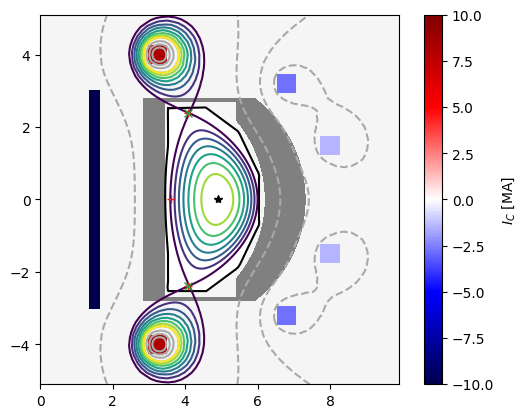

In [10]:
#Plot equilibrium and print statistics
mygs.print_info()
fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_symmap=True,coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]')
mygs.plot_psi(fig,ax,xpoint_color=None,vacuum_nlevels=4)
mygs.plot_constraints(fig,ax)

## Linear stability and VDE initialization

Before the coupled run we characterize the equilibrium's vertical stability and seed a VDE.
\ref OpenFUSIONToolkit.TokaMaker.TokaMaker.compute_linear_stability "compute_linear_stability()"
returns the most unstable eigenmodes and their growth rates. We then perturb the equilibrium flux $\psi$ with the vertical mode
and set it as the initial condition via \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.set_psi "set_psi()",
so the plasma will drift vertically once the time-dependent solve begins.

Growth rate = 6.3316E+00 [s^-1]
Growth time = 1.5794E-01 [s]


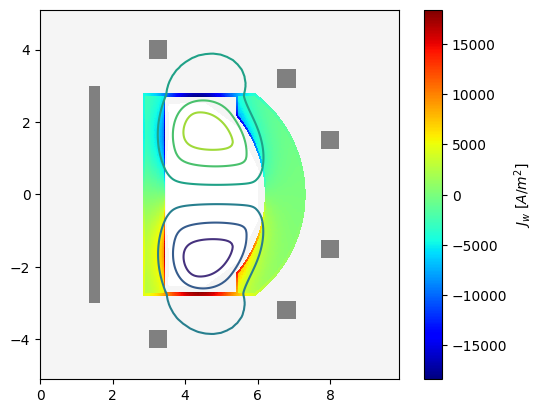

In [11]:
#Compute and plot vertically unstable mode
growth_rates, eig_modes = mygs.compute_linear_stability(5.E3,10,False) 
fig, ax = plt.subplots()
mygs.plot_machine(fig,ax,limiter_color=None)
mygs.plot_psi(fig,ax,psi=eig_modes[1,:],normalized=False,xpoint_color=None,opoint_color=None)
mygs.plot_eddy(fig,ax,dpsi_dt=eig_modes[1,:]*abs(growth_rates[1]))
print('Growth rate = {0:.4E} [s^-1]'.format(growth_rates[1]))
print('Growth time = {0:.4E} [s]'.format(1.0/growth_rates[1]))

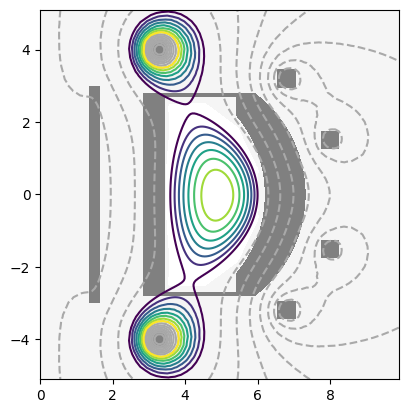

In [12]:
#Perturb equilibrium solution with vertically unstable mode and plot initial condition
psi0 = vde_eq.get_psi(normalized = False)
max_loc = eig_modes[1,:].argmax()
psi_ic = psi0-np.sign(mygs.r[max_loc,1])*eig_modes[1,:]*(vde_eq.psi_bounds[1]-vde_eq.psi_bounds[0])/eig_modes[1,max_loc]/50.0

fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,limiter_color=None)
mygs.plot_psi(fig,ax,psi=vde_eq.abspsi_to_normalized(psi_ic),xpoint_color=None,opoint_color=None)
mygs.set_psi(psi_ic)

## Coupled MUG/TokaMaker time-dependent simulation

We now evolve the perturbed equilibrium **together** with the MHD response of the conducting
blanket. The coupled solver advances the TokaMaker Grad-Shafranov equilibrium and the MUG
incompressible-MHD fields (velocity, pressure, poloidal flux $\psi$, and $F=RB_{\phi}$) in the
conducting regions simultaneously. This captures the flow and current density driven in the blanket
by the changing magnetic field as the plasma moves vertically during the VDE, and how that fluid motion feeds back on the evolution of the plasma.

### Build and set up the coupled simulation

A \ref OpenFUSIONToolkit.TokaMaker.mug_tok.MUGToksim "MUGToksim" object is constructed directly from
the solved `TokaMaker` instance, reusing its mesh, finite-element representation, and active
equilibrium (borrowed, not copied). \ref OpenFUSIONToolkit.TokaMaker.mug_tok.MUGToksim.setup "setup()"
then configures the coupled solve:

- `dt`, `lin_tol`, `nl_tol`: timestep [s] and the linear/nonlinear solver tolerances.
- `mhd_regions`: the conducting-region names (from `cond_dict`) where the MHD solve is active.
- `density` [kg/m³] and `viscosity` [Pa·s]: the mass density and dynamic viscosity in each MHD region,
  aligned with `mhd_regions`.

We use fluid properties of liquid lead-lithium for the blanket regions. By default the flow is incompressible (`incomp=True`) and toroidal flow is disabled
(`allow_toroidal_flow=False`).

In [13]:
from OpenFUSIONToolkit.TokaMaker import MUGToksim

# Build the coupled simulation from the solved equilibrium 
mysim = MUGToksim(mygs)

dt = 5.E-2/growth_rates[1]
mysim.setup(
    dt=dt,      # timestep [s]
    lin_tol=1.0e-11,
    nl_tol=1.0e-9,
    mhd_regions=['BLANKET_INNER', 'BLANKET_OUTER'],
    density=[9806.0, 9806.0],        # [kg/m^3]
    viscosity=[1.0e-3, 1.0e-3],      # dynamic viscosity [Pa-s]
)



**** Creating Lagrange FE space
  Order  =    1
  Minlev =   -1



### Advance the coupled solution in time

Each call to \ref OpenFUSIONToolkit.TokaMaker.mug_tok.MUGToksim.step "step()" advances the coupled
system by one timestep, returning the updated time and timestep along with the nonlinear/linear
iteration counts and retry count. We loop for a number of steps to follow the blanket's MHD response
as the VDE develops.

In [14]:
import time
sim_time = 0.0
nplot = 1
nstatus = 2
times = [sim_time]
results = [mygs.copy_eq()]
t00 = time.perf_counter()

for i in range(140):
    t0 = time.perf_counter()
    sim_time, _, nl_its, lin_its, nretry = mysim.step(sim_time,dt)
    t1 = time.perf_counter()
    if i % nstatus == 0:
        print('{0:.5E} {1:.5E} {2:4d} {3:4d} {5:8.3f} {4:4d}'.format(sim_time,dt,nl_its,lin_its,nretry,t1-t0))
    results.append(mygs.copy_eq())
    times.append(sim_time)
t1 = time.perf_counter()
print('Total time = {0:8.3f}'.format(t1-t00))

7.89693E-03 7.89693E-03    3   50    8.525    0
2.36908E-02 7.89693E-03    3   17    6.064    0
3.94847E-02 7.89693E-03    2   15    5.864    0
5.52785E-02 7.89693E-03    2   16    6.104    0
7.10724E-02 7.89693E-03    3   18    6.312    0
8.68663E-02 7.89693E-03    3   19    6.357    0
1.02660E-01 7.89693E-03    3   18    6.235    0
1.18454E-01 7.89693E-03    3   18    6.267    0
1.34248E-01 7.89693E-03    3   19    6.305    0
1.50042E-01 7.89693E-03    3   19    6.381    0
1.65836E-01 7.89693E-03    3   19    6.497    0
1.81629E-01 7.89693E-03    3   19    6.369    0
1.97423E-01 7.89693E-03    3   19    6.311    0
2.13217E-01 7.89693E-03    3   20    6.376    0
2.29011E-01 7.89693E-03    3   20    6.386    0
2.44805E-01 7.89693E-03    3   20    6.450    0
2.60599E-01 7.89693E-03    3   21    6.576    0
2.76393E-01 7.89693E-03    3   19    6.363    0
2.92187E-01 7.89693E-03    3   19    6.329    0
3.07980E-01 7.89693E-03    3   19    6.304    0
3.23774E-01 7.89693E-03    3   18    6.2

### Retrieve and plot the MHD fields

Field values at the mesh nodes are obtained with
\ref OpenFUSIONToolkit.TokaMaker.mug_tok.MUGToksim.get_field "get_field()", which returns a tuple
`(mask, field)`:

- `mask` is a per-cell boolean array that restricts plotting to where the field is physically defined
  (e.g. only the MHD regions for velocity). It is applied to the triangle list at plot time, i.e.
  `mysim.lc[mask]`.
- `field` holds the values at the mesh nodes (`mysim.r`). The vector fields — `'velocity'` and
  `'current density'` — are returned as `(ndof, 3)` arrays with columns ordered (R, phi, Z); scalar
  fields (`'pressure'`, `'F'`, `'psi'`) are 1D.

**Note:** `'pressure'` is a *lower-order* field than velocity, F, and the current density, so it
lives on its own, coarser set of nodes and triangles. It must therefore be plotted against
`mysim.pressure_r` and `mysim.pressure_lc`, and its `mask` indexes `mysim.pressure_lc` — **not** the
`mysim.r` / `mysim.lc` used for the main-order fields.


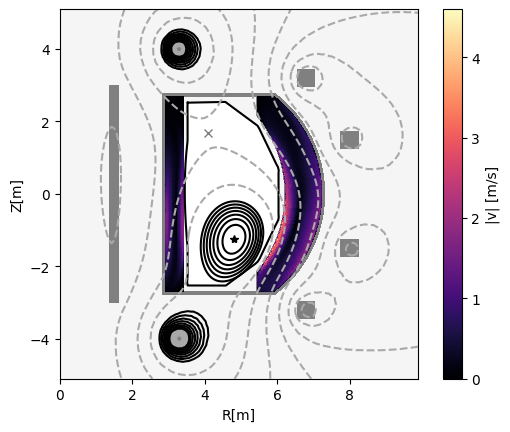

In [15]:
#Plot device and equilibrium
fig,ax = plt.subplots()
mygs.plot_machine(fig,ax)
mygs.plot_psi(fig,ax, plasma_color = 'k')
ax.set_xlabel('R[m]')  
ax.set_ylabel('Z[m]')

#Extract velocity field and plot
mask, vel = mysim.get_field('velocity')   
vmag = np.linalg.norm(vel, axis=1)

clf = ax.tripcolor(
    mysim.r[:,0],
    mysim.r[:,1], 
    mysim.lc[mask,:],
    vmag,
    cmap='magma',
    vmin = 0.0,
    vmax = np.max(np.abs(vmag))
)
cb = fig.colorbar(clf,ax=ax, label = '|v| [m/s]')

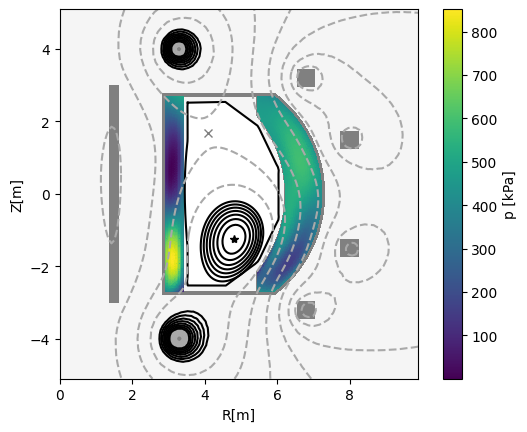

In [16]:
#Plot device and equilibrium
fig,ax = plt.subplots()
mygs.plot_machine(fig,ax)
mygs.plot_psi(fig,ax, plasma_color = 'k')
ax.set_xlabel('R[m]')  
ax.set_ylabel('Z[m]')

#Extract pressure field and plot
mask, p = mysim.get_field('pressure', cell_centered=True)   

clf = ax.tripcolor(
    mysim.pressure_r[:,0],
    mysim.pressure_r[:,1], 
    mysim.pressure_lc[mask,:],
    p[mask]/1000,
    cmap='viridis',
    vmin = np.min(p)/1000,
    vmax = np.max(p)/1000
)
cb = fig.colorbar(clf,ax=ax, label = 'p [kPa]')

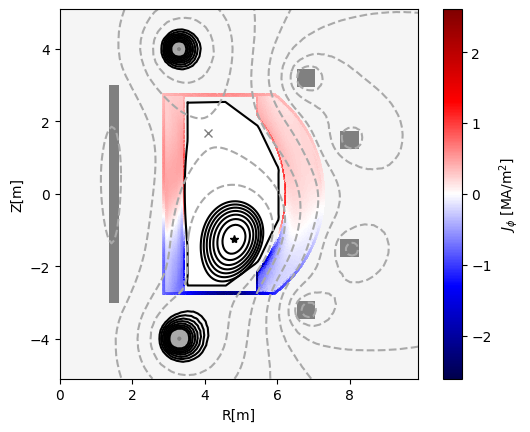

In [17]:
#Plot device and equilibrium
fig,ax = plt.subplots()
mygs.plot_machine(fig,ax)
mygs.plot_psi(fig,ax, plasma_color = 'k')
ax.set_xlabel('R[m]')  
ax.set_ylabel('Z[m]')

#Extract toroidal current density field and plot
mask, curr = mysim.get_field('current density', cell_centered=True)

clf = ax.tripcolor(
    mysim.r[:,0],
    mysim.r[:,1], 
    mysim.lc[mask,:],
    curr[mask,1]/1E6,
    cmap='seismic',
    vmin = -max(np.abs(curr[mask,1]))/1E6,
    vmax = max(np.abs(curr[mask,1]))/1E6
)
cb = fig.colorbar(clf,ax=ax, label = r'$J_{\phi}$ [MA/$\mathrm{m}^2$]')